# Notebook 0: Preliminaries - Numpy & Pandas
For the Techniques of AI course, you will be working with Numpy and Pandas a lot. If you are not familiar with these Python packages, we recommend reading this notebook.

In [2]:
import numpy as np
import pandas as pd
import sklearn # scikit-learn library

## 1. Introduction to NumPy

Python is a very popular programming language in science and particularly in ML but it is not due to its computing speed. In fact, Python is quite slow if we want to use it in itself to compute mathematical operations such as matrix or vector multiplication and addition, which are a frequent type of operation in ML algorithms. What makes Python popular is its large choice of libraries giving access to powerful algorithms written in some other more computationally efficient languages, such as C or Fortran.

Numpy is the most important Python library for mathematical operations. It allows to transform Python lists into a numpy object, more specifically a numpy ndarray (an $n$-dimensional array), for which Numpy allows us to apply a variety of mathematical operations very easily and very efficiently in terms of computing speed (much more than if we were to write everything in Python code). Numpy is a central Python library and most of the other scientific Python libraries also use its ndarray data format.

I invite you to check the introduction to the Numpy library: https://numpy.org/doc/stable/user/absolute_beginners.html

Let's look into a few operations that can be done using Numpy:

In [3]:
# we can create a vector from a python list like this
vector_a = [1,2,3]
vector_a = np.array(vector_a)

vector_a

array([1, 2, 3])

In [4]:
# or directly like this
vector_b = np.array([4,5,6])

# there is a bunch of other ways to create arrays
vector_c = np.ones(3, dtype=int) # the argument is the dimensional shape of the tensor, here we create a vector of dim=3

# then we can do operations such as additions
print(f"{vector_a} + {vector_c} = {vector_a + vector_c}")

[1 2 3] + [1 1 1] = [2 3 4]


We can do the Hadamard product (or element wise multiplication): $ \vec{a} \odot \vec{b} = (a^i * b^i)$

In [5]:
# Hadamard product

print(f"{vector_a} * {vector_b} = {vector_a * vector_b}")

[1 2 3] * [4 5 6] = [ 4 10 18]


Or the dot product: $\vec{a} \cdot \vec{b} = \sum_{i} a_i b_i$
<img src="https://d138zd1ktt9iqe.cloudfront.net/media/seo_landing_files/matrix-representation-of-dot-product-1626103121.png"/>

In [6]:
# the dot product 
np.dot(vector_a,vector_b)

np.int64(32)

Let's see a few examples of operations using matrices now

In [7]:
# np.ones(Rows, Columns)

A = np.ones((4,3),dtype=int) 
A

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]])

In [8]:
# We can check its shape (= its dimensions)
A.shape

(4, 3)

In [9]:
# similarly for our vector a
vector_a.shape

(3,)

In [10]:
# we can perform the matrix multiplication
A.dot(vector_a) # it is the same as doing np.dot(A, vector_a)

array([6, 6, 6, 6])

In [11]:
# We can generate a random matrix with values drawn from a normal distribution [0,1)
B = np.random.randn(4,3)
B

array([[-0.99678107,  1.22651547,  0.30915125],
       [-1.47380479,  0.86188856,  0.37828633],
       [-0.60834985, -0.64410978,  1.33994236],
       [-0.53158755,  0.25684742, -0.12513558]])

Numpy allows us to obtain easily the transposed of a matrix, to perform for example the product $A^T \cdot B$

In [12]:
np.dot(A.T, B)

array([[-3.61052325,  1.70114167,  1.90224437],
       [-3.61052325,  1.70114167,  1.90224437],
       [-3.61052325,  1.70114167,  1.90224437]])

## 2. Introduction to Pandas

Pandas is a powerful Python library that helps you easily organize, analyze, and manipulate data in tables (like spreadsheets) using structures called DataFrames and Series. A Series is a one-dimensional labeled array (like a single column of data with row labels), while a DataFrame is a two-dimensional labeled table made up of multiple Series arranged as columns.


We will use the Wine dataset from scikit-learn to explore some pandas basics: 
- loading data into a `DataFrame`
- inspecting it 
- selecting subsets
- filtering rows
- summarizing with groupby/aggregations

**Note**: scikit-learn is a widely used machine learning library which we will often use troughout the course.

In [13]:
# Import the dataset from the sklearn library
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.frame  # pandas DataFrame with features + target column

#### Inspecting a DataFrame

Key attributes to remember:

- Columns store features; rows are indexed observations.

- `.head()` gives the first rows; `.info()` summarizes columns and missing values; `.describe()` provides numeric stats.

- The target labels here are integers (0/1/2) mapping to wine cultivars.

In [14]:
# Quick look at the table
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [15]:
# Data types and missing values summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [16]:
# Basic descriptive statistics for numeric columns
df.describe().T  # transpose to read more easily

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


#### Selecting columns and rows

Common patterns:

- Select one column: `df['alcohol']`

- Select multiple columns: `df[['alcohol', 'malic_acid']]`

- Row slices: `df.iloc[0:5]` (position) or `df.loc[0:4]` (label)

- Boolean mask: `df[df['alcohol'] > 13]`

In [ ]:
# Column(s) and row selections

one_col = df['alcohol']
two_cols = df[['alcohol', 'malic_acid']]

first_five_rows = df.iloc[0:5]

mask_high_alcohol = df[df['alcohol'] > 13]

print("--- 1 column ---")
print(one_col.head())
print("--- 2 columns ---")
print(two_cols.head())
print("--- first five rows ---")
print(first_five_rows.head())


--- 1 column ---
0    14.23
1    13.20
2    13.16
3    14.37
4    13.24
Name: alcohol, dtype: float64
--- 2 columns ---
   alcohol  malic_acid
0    14.23        1.71
1    13.20        1.78
2    13.16        2.36
3    14.37        1.95
4    13.24        2.59
--- first five rows ---
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24     

In [18]:
print("--- high alcohol ---")
print(mask_high_alcohol.head())

--- high alcohol ---
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline 

#### Filtering and sorting

- Boolean filters stack: `(df['alcohol'] > 13) & (df['color_intensity'] > 5)`

- Sort values: `df.sort_values(by='alcohol', ascending=False)`

In [19]:
# Filter and sort examples
filtered = df[(df['alcohol'] > 13) & (df['color_intensity'] > 5)]
filtered.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0


In [20]:
# Sort example
sorted_df = df.sort_values(by='alcohol', ascending=False)
sorted_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0
13,14.75,1.73,2.39,11.4,91.0,3.10,3.69,0.43,2.81,5.40,1.25,2.73,1150.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
14,14.38,1.87,2.38,12.0,102.0,3.30,3.64,0.29,2.96,7.50,1.20,3.00,1547.0,0
46,14.38,3.59,2.28,16.0,102.0,3.25,3.17,0.27,2.19,4.90,1.04,3.44,1065.0,0


#### Grouping and summarizing

- `groupby('target').mean()` aggregates by wine class.

- `value_counts()` counts categorical values (here `target`).

- Missing values: `df.isna().sum()` to check; `df.fillna(...)` to impute.

- Tiny exercise: compute the average alcohol per class and sort descending.

In [21]:
# We group the DataFrame by the 'target' column (wine class), then calculate the mean alcohol content for each class.
# Finally, we sort the resulting means in descending order to see which class has the highest average alcohol.
group_means = df.groupby('target')['alcohol'].mean().sort_values(ascending=False)
group_means

target
0    13.744746
2    13.153750
1    12.278732
Name: alcohol, dtype: float64

In [22]:
# Counts of each class in 'target' 
counts = df['target'].value_counts()
print(counts)

target
1    71
0    59
2    48
Name: count, dtype: int64


In [23]:
# missing values per column
missing = df.isna().sum()
print(missing)

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


#### Quick plot

With matplotlib, you can make a fast bar plot of class counts:

`df['target'].value_counts().plot.bar()`

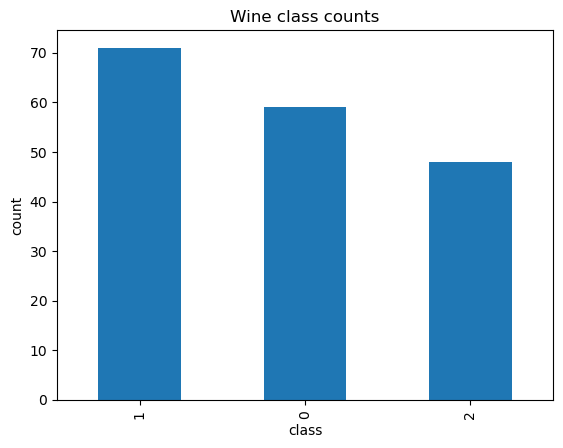

In [24]:
# Quick bar plot of class counts
import matplotlib.pyplot as plt

counts.plot.bar()
plt.title('Wine class counts')
plt.xlabel('class')
plt.ylabel('count')
plt.show()

**Disclaimer**: GenAI was used to improve the contents of this notebook.